<a href="https://colab.research.google.com/github/jcmachicao/cur_MMAI__multimodal/blob/main/cur_IAMM___analisis_sonidos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow tensorflow-hub librosa numpy

In [2]:
import numpy as np
import tensorflow as np_tf
import tensorflow_hub as hub
import librosa

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


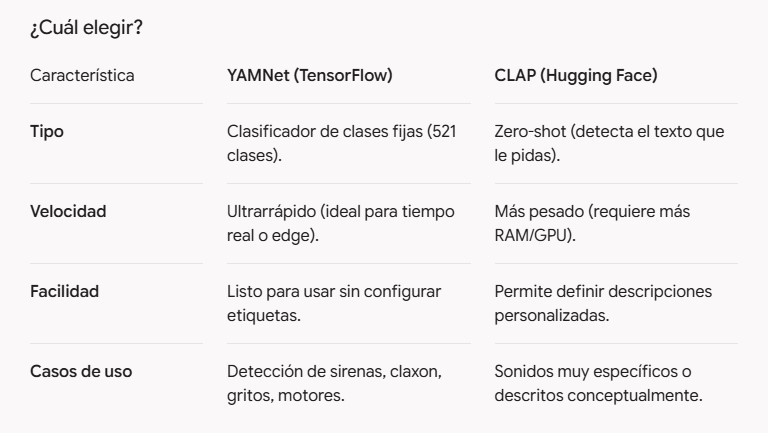

In [3]:
# 1. Cargar el modelo preentrenado de YAMNet desde TensorFlow Hub
model = hub.load('https://tfhub.dev/google/yamnet/1')

# Cargar las etiquetas del modelo (los nombres de las 521 clases)
class_map_path = model.class_map_path().numpy().decode('utf-8')
class_names = [line.strip().split(',')[1] for line in open(class_map_path).readlines()[1:]]

In [4]:
def analizar_audio(ruta_archivo):
    # 2. Cargar el audio corto y re-muestrear a 16kHz (frecuencia requerida por YAMNet)
    audio_data, sr = librosa.load(ruta_archivo, sr=16000, mono=True)

    # 3. Ejecutar la inferencia con el modelo
    scores, embeddings, spectrogram = model(audio_data)

    # Promediar las probabilidades a lo largo del tiempo del audio
    mean_scores = np.mean(scores, axis=0)

    # 4. Obtener las N clases con mayor probabilidad
    top_n = 5
    top_indices = np.argsort(mean_scores)[::-1][:top_n]

    print(f"\nResultados para: {ruta_archivo}")
    print("-" * 40)
    for i in top_indices:
        probabilidad = mean_scores[i] * 100
        etiqueta = class_names[i]
        print(f"{etiqueta}: {probabilidad:.2f}%")

In [ ]:
ruta = "drive/My Drive/"

In [ ]:
analizar_audio("mi_audio_3sec.wav")